# XBTorch::Example 02:Synthesize Device Datasets

## Introduction

In this example, we will see how to extract device datasets [i.e. (G, ΔG / pulse) data points] from an XBTorch device model. 

## Getting Started

Let's import necessary dependencies and write a helper function to assist in visualization.

In [1]:
# General Imports
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# XBTorch imports
from xbtorch.devices.presets import AnalyticalIdeal, AnalyticalReal, TabularAnalyticalReal
from xbtorch.devices.utils import synthesize_G_dG_dataset

No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'


XBTorch provides a helpful utility function, `synthesize_G_dG_dataset()` within the `xbtorch.devices.utils` submodule, which we can utilize for this operation.

In [3]:
# Let's write a simple plotting function
def plot_G_vs_dG(device, num_points):
    """
        Plot conductance (G) vs delta conductance (ΔG) data points.
        The datasets are synthesized using Algorithm 2 from Ref. [1].

        Inputs 
            device: the XBTorch device model object.
            cycle: total number of cycles to repeat the sweeping process.
    """
    set_dataset = synthesize_G_dG_dataset(device, set=True, num_points=num_points, disable_filtering=False)
    reset_dataset = synthesize_G_dG_dataset(device, set=False, num_points=num_points, disable_filtering=False)

    plt.figure()
    plt.scatter(set_dataset[:, 0], set_dataset[:, 1], label='SET', s=10, alpha=0.5, c='C0')
    plt.legend()
    plt.xlabel('Initial conductance, G (S)')
    plt.ylabel('Conductance change, ΔG (S)')

    plt.figure()
    plt.scatter(reset_dataset[:, 0], reset_dataset[:, 1], label='RESET', s=10, alpha=0.5, c='C1')
    plt.legend()
    plt.xlabel('Initial conductance, G (S)')
    plt.ylabel('Conductance change, ΔG (S)')
    
    return set_dataset, reset_dataset

## Synthesizing Device Datasets

We can now instantiate an XBTorch device model and generate or synthesize device datasets. Such datasets can then be utilized to a) study device responses, or b) create custom tabular models using our data-driven modeling methodology. For more information on device models and available presets, see Example 01. 

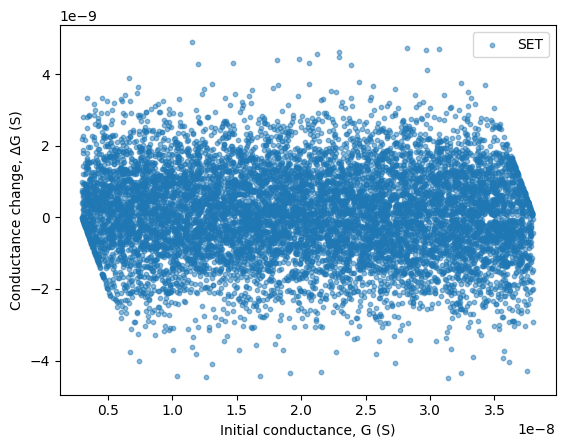

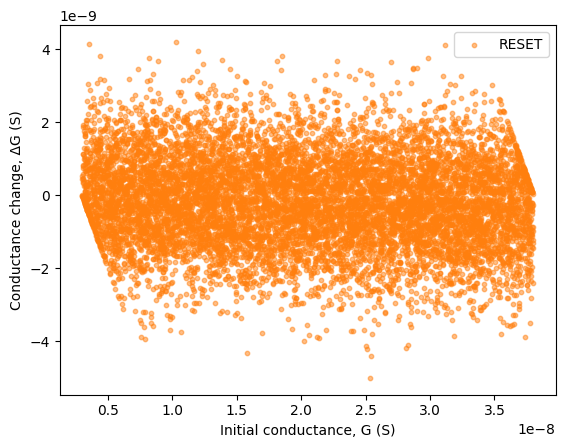

In [4]:
# Analytical Device Models
deviceReal =  AnalyticalReal()

p1 = plot_G_vs_dG(deviceReal, num_points=10000)

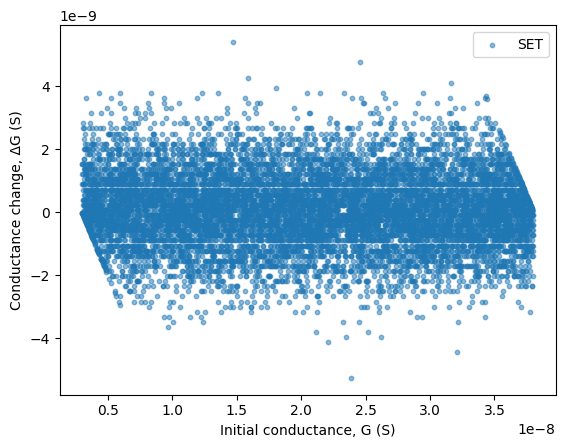

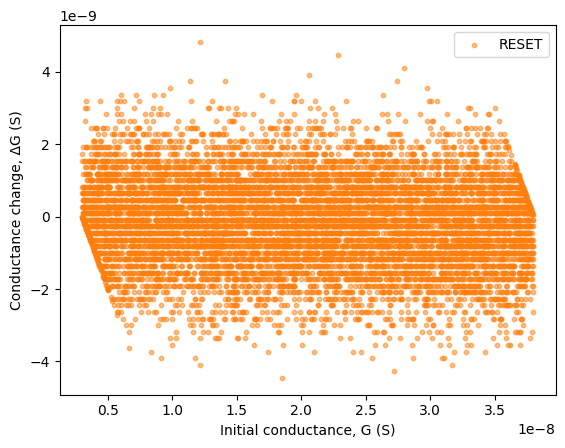

In [5]:
# Tabular Device Models
tabularDev = TabularAnalyticalReal()

p2 = plot_G_vs_dG(tabularDev, num_points=10000)

## Conclusion
We now know how to extract (G, ΔG/pulse) datasets from XBTorch device models. When building custom models, this is the kind of dataset we would require four our data-driven modeling methodology, which would generate jump table pairs (one for SET, another for RESET) to be used for neural network simulations. Like the previous example, if you want to dive deeper into how the simulated devices are getting pulsed, looking into `synthesize_G_dG_dataset()` from `xbtorch.devices.utils` would be the recommended place to start!

## References
1. Yousuf, O., Hossen, I., Daniels, M. W., Lueker-Boden, M., Dienstfrey, A., & Adam, G. C. (2023). Device Modeling Bias in ReRAM-based Neural Network Simulations. IEEE Journal on Emerging and Selected Topics in Circuits and Systems, 13(1), 382-394.